# DSA 5102 - Programming Assignment 2

I used OpenAI Codex to assist with this assignment in the following ways:
1. Reviewing the assignment requirements and clarifying the tasks.
2. Using the lecturer’s DSA5102_PCA.ipynb notebook as a reference to explain the basic concepts and practical use of PCA and autoencoders, and providing additional explanations of standardization, the elbow method, K-means, Gaussian mixture models, reconstruction MSE, silhouette score, and adjusted Rand index.
3. Debugging coding errors, improving the formatting to enhance the code readability.
4. Helping improve and revise the correctness and fluency of parts of the English explanations and conclusions.

I ran the code in my notebook, reviewed the outputs, and discussed the explanations to improve my understanding. I take responsibility for the final content and accuracy of the submitted work.

## Description

In this second homework, you will explore one dataset using `PCA`, an
`autoencoder`, `k-means` and a `Gaussian mixture model`. The goals are to
understand dimension reduction and clustering, and to relate their results
to patterns visible in the data.

The recorded output, `Class`, is nominal: it contains **seven different labels**. This provides a reference throughout the assignment;
neither the retained dimension nor the number of clusters must equal seven.

## Instructions

Complete the questions directly in this notebook, with code, outputs and
brief explanations. Grading is based on scientific correctness and clear
documentation. There are **10 points**.

Use the supplied split throughout. Exclude `Class` from model inputs and use it only for the final
clustering evaluation. Choose dimensions and cluster counts using training
data. 

## Dataset

The [Dry Bean dataset](https://archive.ics.uci.edu/dataset/602/dry+bean+dataset)
contains 13,611 beans with 16 numerical measurements of size and shape,
including area, perimeter and compactness, alongside the variety label `Class`.
The dataset `dry_bean.csv` is supplied beside this notebook.

Citation: *Dry Bean* [Dataset]. (2020). UCI Machine Learning Repository.
[DOI: 10.24432/C50S4B](https://doi.org/10.24432/C50S4B).
[CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).
The CSV preserves the original Excel table's columns and records.

In [58]:
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 42
data = pd.read_csv('./dry_bean.csv')
data.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [59]:
features = data.columns.drop('Class')
data = data.drop_duplicates(subset=features).reset_index(drop=True)
train, test = train_test_split(data, test_size=0.2, random_state=SEED)
X_train, X_test = train[features], test[features]
print(f'Training: {X_train.shape}; test: {X_test.shape}')

Training: (10834, 16); test: (2709, 16)


## Question 1 (2 points)

Choose three numerical features and visualize their pairwise relationships
using the training data. Briefly describe any correlations, nonlinear patterns
or apparent groups. What might these plots suggest about dimension reduction
and clustering?

In [60]:
# Your code for Question 1
import matplotlib.pyplot as plt
selected_feature = ['Area', 'Perimeter', 'AspectRation']

def plot_scatter(data, x_feature, y_feature, ax):
    scatter = ax.scatter(
        data[x_feature],
        data[y_feature],
        c = data[y_feature],
        cmap = 'viridis',
        marker = '.',
        s = 12,
        alpha = 0.5
    )

    ax.set_xlabel(x_feature)
    ax.set_ylabel(y_feature)
    ax.set_title(f'{x_feature} vs {y_feature}', pad=20)
    ax.set_facecolor('#f8fafc')
    ax.set_axisbelow(True)
    ax.grid(alpha = 0.2)
    ax.figure.colorbar(
        scatter,
        ax = ax,
        label = y_feature,
        shrink = 0.8,
        pad = 0.03
    )

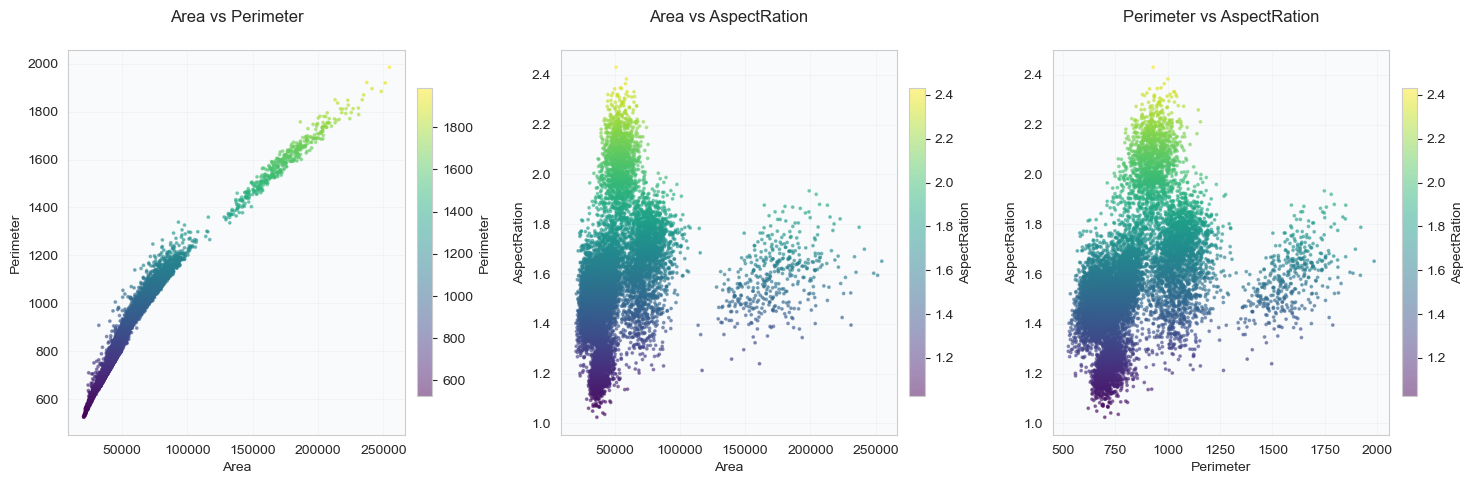

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_scatter(X_train, selected_feature[0], selected_feature[1], axes[0])
plot_scatter(X_train, selected_feature[0], selected_feature[2], axes[1])
plot_scatter(X_train, selected_feature[1], selected_feature[2], axes[2])
plt.show()

Write your observations here.

I select Area, Perimeter and AspectRation.
Area and Perimeter show a strong positive relationship:large beans usually have longer perimeters.The pattern is slightly curved rather than a straight line.

AspecRation has a weaker relationship with size, since beans with similar areas or perimeters can still have different shapes.

These plots suggest that Area and Perimeter contain some similar information, so dimension reduction may help reduce this repetition.The curved pattern also suggests that some relationships are nonlinear.There is a relatively separate group of larger beans,which suggests that clustering could be useful.

## Question 2 (4 points)

Using all 16 features:

1. Apply PCA and plot its eigenvalues in decreasing order. Use the visual
   elbow method to choose and justify the number of retained components, $d$.
   Report the training variance retained and the training/test reconstruction
   MSE. **(2 points)**
2. Train a nonlinear autoencoder with the same bottleneck dimension $d$, using
   your PCA choice above.
   Compare its training/test reconstruction MSE with PCA. **(2 points)**

Use the same standardized features for both methods. Briefly explain why
scaling matters, discuss your findings and relate them to Question 1.

*Hint: Reconstruction MSE compares the input with its reconstruction,
averaged over all observations and features.*

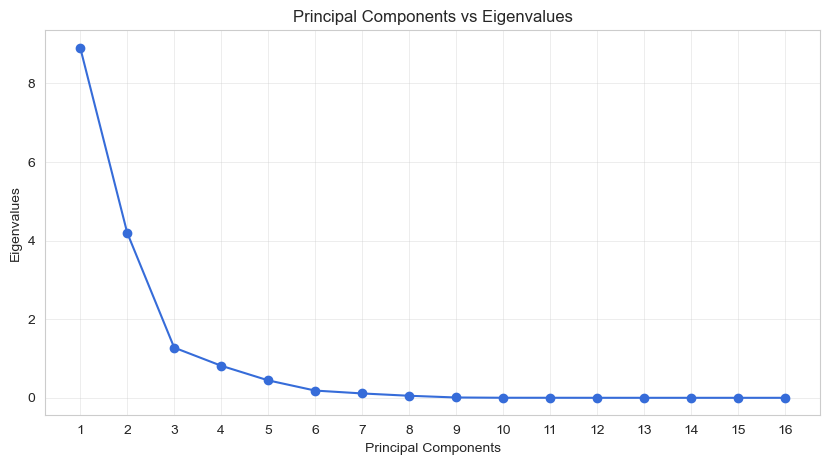

Training variance retained: 89.87%
Training reconstruction MSE: 0.101260
Test reconstruction MSE: 0.098708


In [62]:
# Your code for Question 2
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import seaborn as sns
sns.set_style('whitegrid')
scaler = StandardScaler()

# Standardization puts features on a similar scale, preventing features with larger numerical variation from dominating the model
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA()
pca.fit(X_train_scaled)

eigenvalues = pca.explained_variance_

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, 17), eigenvalues, marker='o')
ax.set_xticks(range(1, 17))
ax.set_xlabel('Principal Components')
ax.set_ylabel('Eigenvalues')
ax.set_title('Principal Components vs Eigenvalues')
plt.show()

# From the plot graph, we know that when d>3, the changes of eigenvalues is much smaller than d<=3, so we take d=3
d = 3
pca = PCA(n_components=d)
pca.fit(X_train_scaled)

train_scores = pca.transform(X_train_scaled)
test_scores = pca.transform(X_test_scaled)
train_recon = pca.inverse_transform(train_scores)
test_recon = pca.inverse_transform(test_scores)

variance_retained = pca.explained_variance_ratio_.sum()
train_mse = mean_squared_error(X_train_scaled, train_recon)
test_mse = mean_squared_error(X_test_scaled, test_recon)

print(f'Training variance retained: {variance_retained:.2%}')
print(f'Training reconstruction MSE: {train_mse:.6f}')
print(f'Test reconstruction MSE: {test_mse:.6f}')

In [63]:
import torch
from torch import nn
from torch.utils.data import DataLoader

class Autoencoder(nn.Module):
    def __init__(self, d):
        super().__init__()

        # encoder:16 -> 64 -> d
        self.encoder = nn.Sequential(
            nn.Linear(16, 64),
            nn.ReLU(),
            nn.Linear(64, d)
        )
        # decoder:d -> 64 -> 16
        self.decoder = nn.Sequential(
            nn.Linear(d, 64),
            nn.ReLU(),
            nn.Linear(64, 16)
        )

    def forward(self, X):
        compressed = self.encoder(X)
        return self.decoder(compressed)

    def fit(self, X, batch_size, epochs):
        training_data = torch.as_tensor(X, dtype=torch.float32)

        training_batches = DataLoader(
            training_data,
            batch_size=batch_size,
            shuffle=True
        )

        device = next(self.parameters()).device
        optimizer = torch.optim.Adam(self.parameters(), lr=0.001)
        loss_function = nn.MSELoss()

        self.train()

        for epoch in range(epochs):
            total_loss = 0.0

            for batch in training_batches:
                batch = batch.to(device)
                optimizer.zero_grad()
                reconstructed = self(batch)
                loss = loss_function(reconstructed, batch)
                loss.backward()
                optimizer.step()
                total_loss += loss.item() * len(batch)

            if (epoch + 1) % 10 == 0:
                average_loss = total_loss / len(training_data)
                print(
                    f'Epoch {epoch + 1}/{epochs} - '
                    f'reconstruction MSE: {average_loss:.6f}'
                )

    def predict(self, X, batch_size=128):
        X = torch.as_tensor(X, dtype=torch.float32)
        device = next(self.parameters()).device

        self.eval()
        reconstructions = []

        with torch.inference_mode():
            for batch in X.split(batch_size):
                reconstructed = self(batch.to(device))
                reconstructions.append(reconstructed.cpu())

        return torch.cat(reconstructions).numpy()

autoencoder = Autoencoder(d=d)

autoencoder.fit(
    X_train_scaled,
    batch_size=128,
    epochs=100
)

ae_train_recon = autoencoder.predict(X_train_scaled)
ae_test_recon = autoencoder.predict(X_test_scaled)

ae_train_mse = mean_squared_error(X_train_scaled, ae_train_recon)
ae_test_mse = mean_squared_error(X_test_scaled, ae_test_recon)

print(f'Autoencoder training MSE: {ae_train_mse:.6f}')
print(f'Autoencoder test MSE: {ae_test_mse:.6f}')

Epoch 10/100 - reconstruction MSE: 0.048394
Epoch 20/100 - reconstruction MSE: 0.043160
Epoch 30/100 - reconstruction MSE: 0.040413
Epoch 40/100 - reconstruction MSE: 0.038758
Epoch 50/100 - reconstruction MSE: 0.037693
Epoch 60/100 - reconstruction MSE: 0.036815
Epoch 70/100 - reconstruction MSE: 0.036070
Epoch 80/100 - reconstruction MSE: 0.035582
Epoch 90/100 - reconstruction MSE: 0.035106
Epoch 100/100 - reconstruction MSE: 0.034786
Autoencoder training MSE: 0.034802
Autoencoder test MSE: 0.035683


Write your explanation here.

The autoencoder achieved lower training and test reconstruction MSE than PCA with the same compressed dimension. This means its reconstructed data was closer to the original input, showing better reconstruction performance.

In Question 1, Area and Perimeter were strongly correlated, suggesting that they contained some repeated information. This supports using dimension reduction. The slightly curved pattern also suggested nonlinear relationships, which the autoencoder may capture more effectively than PCA.

## Question 3 (4 points)

Apply **k-means (2 points)** and a **Gaussian mixture model (2 points)** to
all 16 standardized features. Draw side-by-side elbow plots of training
within-cluster MSE against the number of clusters/components. Choose and
justify a count for each method independently; the counts need not match.

For your chosen models, compare test inertia (within-cluster MSE),
[silhouette score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html)
and [adjusted Rand index (ARI)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html),
using `Class` only for ARI. Briefly explain your findings, your preferred
method and how the results relate to Question 1.


In [64]:
# Your code for Question 3
import numpy as np
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score

# candidate numbers of clusters
K_VALUES = list(range(1, 13))

# two dictionaries, saving different models corresponding to different k
kmeans_models = {}
gmm_models = {}
# a list, saving two types of MSE corresponding to different k
records = []

# choose one candidate cluster for every time
for k in K_VALUES:
    # K-means
    # create K-means model
    kmeans = KMeans(
        n_clusters=k,   # divide into k groups
        n_init=10,      # try 10 sets of initial centers, keep the best one
        random_state=SEED
    )
    kmeans.fit(X_train_scaled)
    kmeans_labels = kmeans.predict(X_train_scaled)
    kmeans_centers = kmeans.cluster_centers_[kmeans_labels]
    kmeans_mse = mean_squared_error(
        X_train_scaled, kmeans_centers
    )
    kmeans_models[k] = kmeans

    # Gaussian mixture model
    # create gmm model
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        n_init=3,
        max_iter=300,
        random_state=SEED
    )
    gmm.fit(X_train_scaled)
    gmm_labels = gmm.predict(X_train_scaled)
    gmm_centers = gmm.means_[gmm_labels]
    gmm_mse = mean_squared_error(
        X_train_scaled, gmm_centers
    )
    gmm_models[k] = gmm

    records.append({
        'k': k,
        'K-means MSE': kmeans_mse,
        'GMM MSE': gmm_mse
    })

    print(f'Finished k = {k}')

elbow_results = pd.DataFrame(records)
print(elbow_results.round(6).to_string(index=False))

Finished k = 1
Finished k = 2
Finished k = 3
Finished k = 4
Finished k = 5
Finished k = 6
Finished k = 7
Finished k = 8
Finished k = 9
Finished k = 10
Finished k = 11
Finished k = 12
 k  K-means MSE  GMM MSE
 1     1.000000 1.000000
 2     0.594582 0.598377
 3     0.436479 0.515709
 4     0.352046 0.417152
 5     0.285377 0.295368
 6     0.254121 0.260749
 7     0.225411 0.261649
 8     0.208320 0.250808
 9     0.198105 0.231826
10     0.183331 0.225609
11     0.174466 0.230021
12     0.166384 0.218530


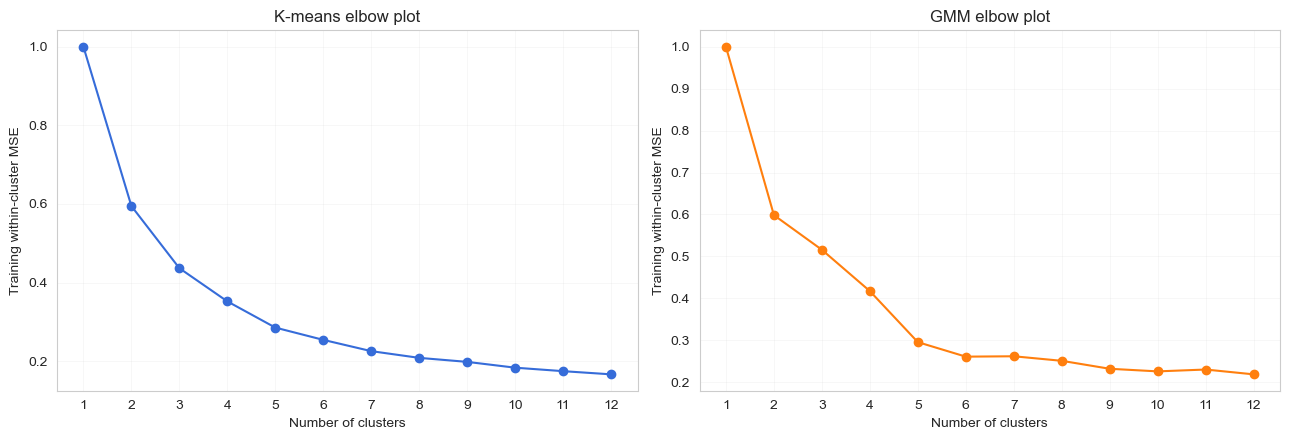

In [65]:
sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(
    elbow_results['k'],
    elbow_results['K-means MSE'],
    marker='o'
)
axes[0].set_title('K-means elbow plot')

axes[1].plot(
    elbow_results['k'],
    elbow_results['GMM MSE'],
    marker='o',
    color='tab:orange'
)
axes[1].set_title('GMM elbow plot')

for ax in axes:
    ax.set_xlabel('Number of clusters')
    ax.set_ylabel('Training within-cluster MSE')
    ax.set_xticks(K_VALUES)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [66]:
best_kmeans = kmeans_models[7]
best_gmm = gmm_models[6]

kmeans_test_labels = best_kmeans.predict(X_test_scaled)
gmm_test_labels = best_gmm.predict(X_test_scaled)

kmeans_test_centers = best_kmeans.cluster_centers_[kmeans_test_labels]
gmm_test_centers = best_gmm.means_[gmm_test_labels]

kmeans_test_mse = mean_squared_error(
    X_test_scaled, kmeans_test_centers
)
gmm_test_mse = mean_squared_error(
    X_test_scaled, gmm_test_centers
)

kmeans_silhouette = silhouette_score(
    X_test_scaled, kmeans_test_labels
)
gmm_silhouette = silhouette_score(
    X_test_scaled, gmm_test_labels
)

kmeans_ari = adjusted_rand_score(
    test['Class'], kmeans_test_labels
)
gmm_ari = adjusted_rand_score(
    test['Class'], gmm_test_labels
)

comparison = pd.DataFrame({
    'Model': ['K-means', 'GMM'],
    'Test within-cluster MSE': [kmeans_test_mse, gmm_test_mse],
    'Silhouette score': [kmeans_silhouette, gmm_silhouette],
    'ARI': [kmeans_ari, gmm_ari]
})

print(comparison.round(6).to_string(index=False))

  Model  Test within-cluster MSE  Silhouette score      ARI
K-means                 0.218870          0.313321 0.668053
    GMM                 0.251282          0.300595 0.695208


Write your explanation here.

For K-means, I choose k=7 as the reduction in training MSE becomes smaller after this point. For GMM, I choose 6 components because the curve shows a clearer elbow around this value. The counts were selected independently from their respective plots.

Within-cluster MSE measures how close records are to their group centers, with lower values being better. The silhouette score measures how compact and well separated the groups are, while ARI measures agreement with the true bean classes; higher values are better for both. K-means achieved a lower test MSE (0.2189 vs 0.2513) and a higher silhouette score (0.3133 vs 0.3006), while GMM achieved a higher ARI (0.6952 vs 0.6681). I prefer K-means because although GMM matches the true classes more closely (higher ARI), but K-means has more compact groups (lower mse) and the groups are separated better (higher silhouette). In Question 1, the pairwise plots suggested some possible groups, especially among larger beans. Question 3 extends this exploration by using all 16 standardized features for clustering.